INFO:fiftyone.zoo.datasets:Downloading split 'validation' to '/root/fiftyone/coco-2017/validation' if necessary


Found annotations at '/root/fiftyone/coco-2017/raw/instances_val2017.json'


INFO:fiftyone.utils.coco:Found annotations at '/root/fiftyone/coco-2017/raw/instances_val2017.json'


Sufficient images already downloaded


INFO:fiftyone.utils.coco:Sufficient images already downloaded


...

 100% |█████████████████████| 3/3 [90.1ms elapsed, 0s remaining, 33.3 samples/s]     


INFO:eta.core.utils: 100% |█████████████████████| 3/3 [90.1ms elapsed, 0s remaining, 33.3 samples/s]     


Dataset 'coco-2017-validation-3' created


INFO:fiftyone.zoo.datasets:Dataset 'coco-2017-validation-3' created


✅ Small COCO dataset loaded


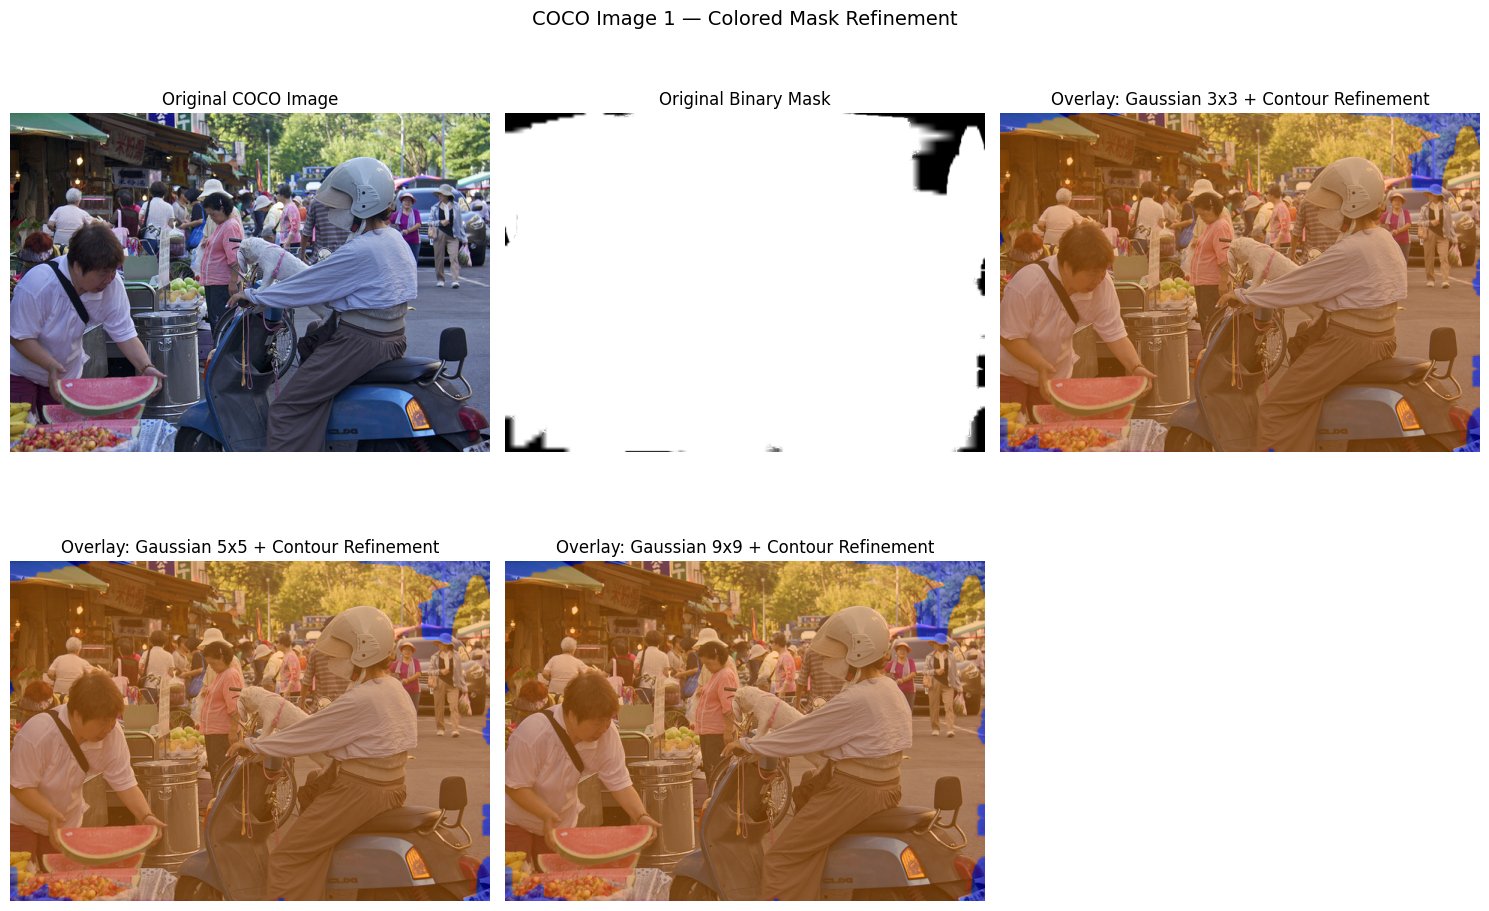

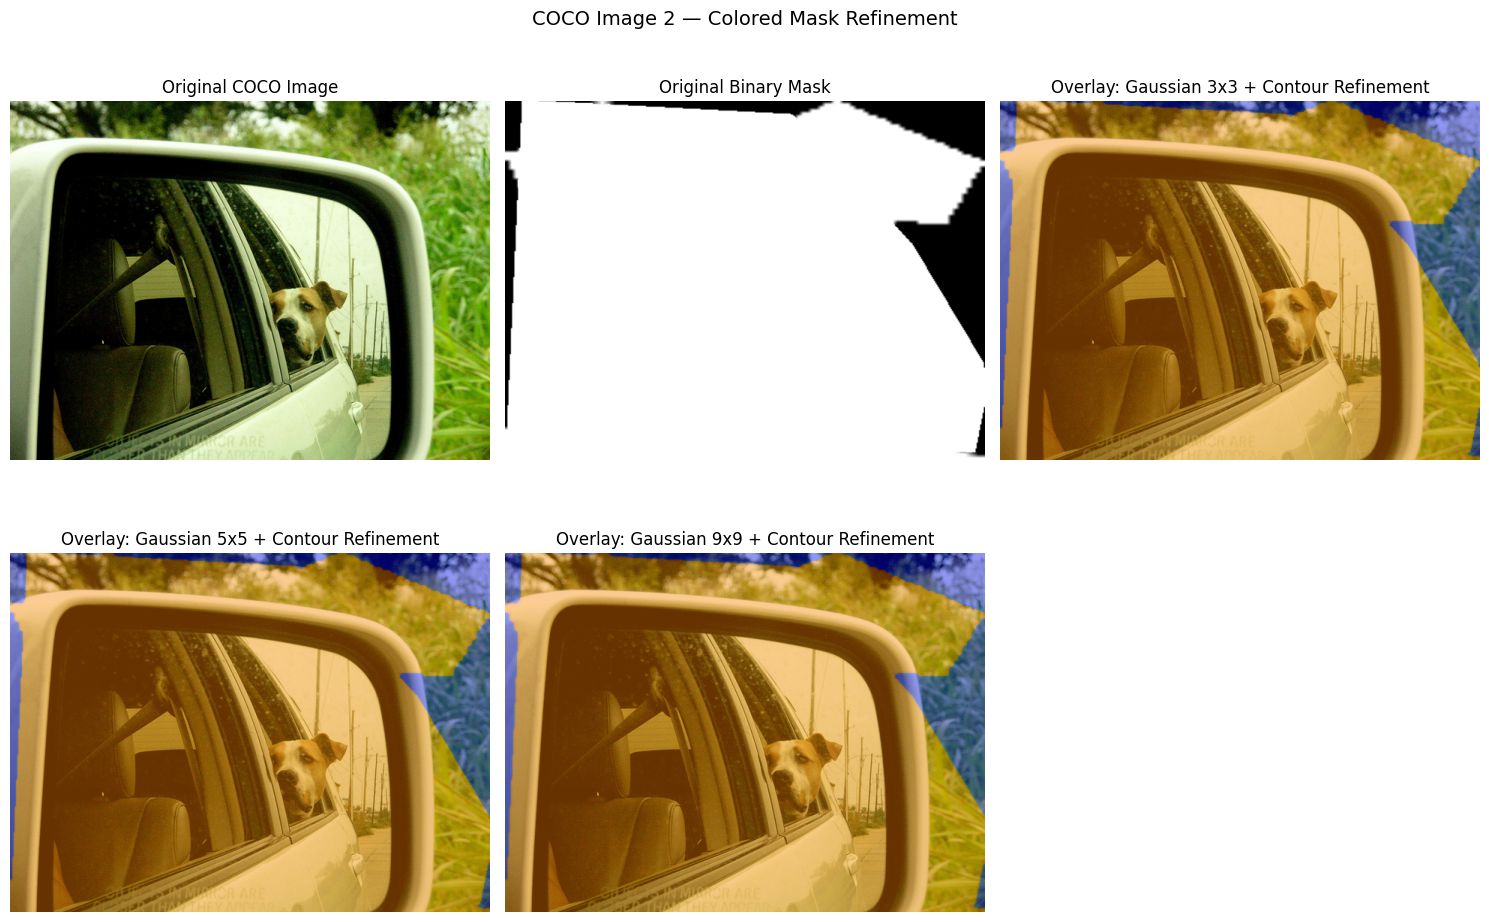

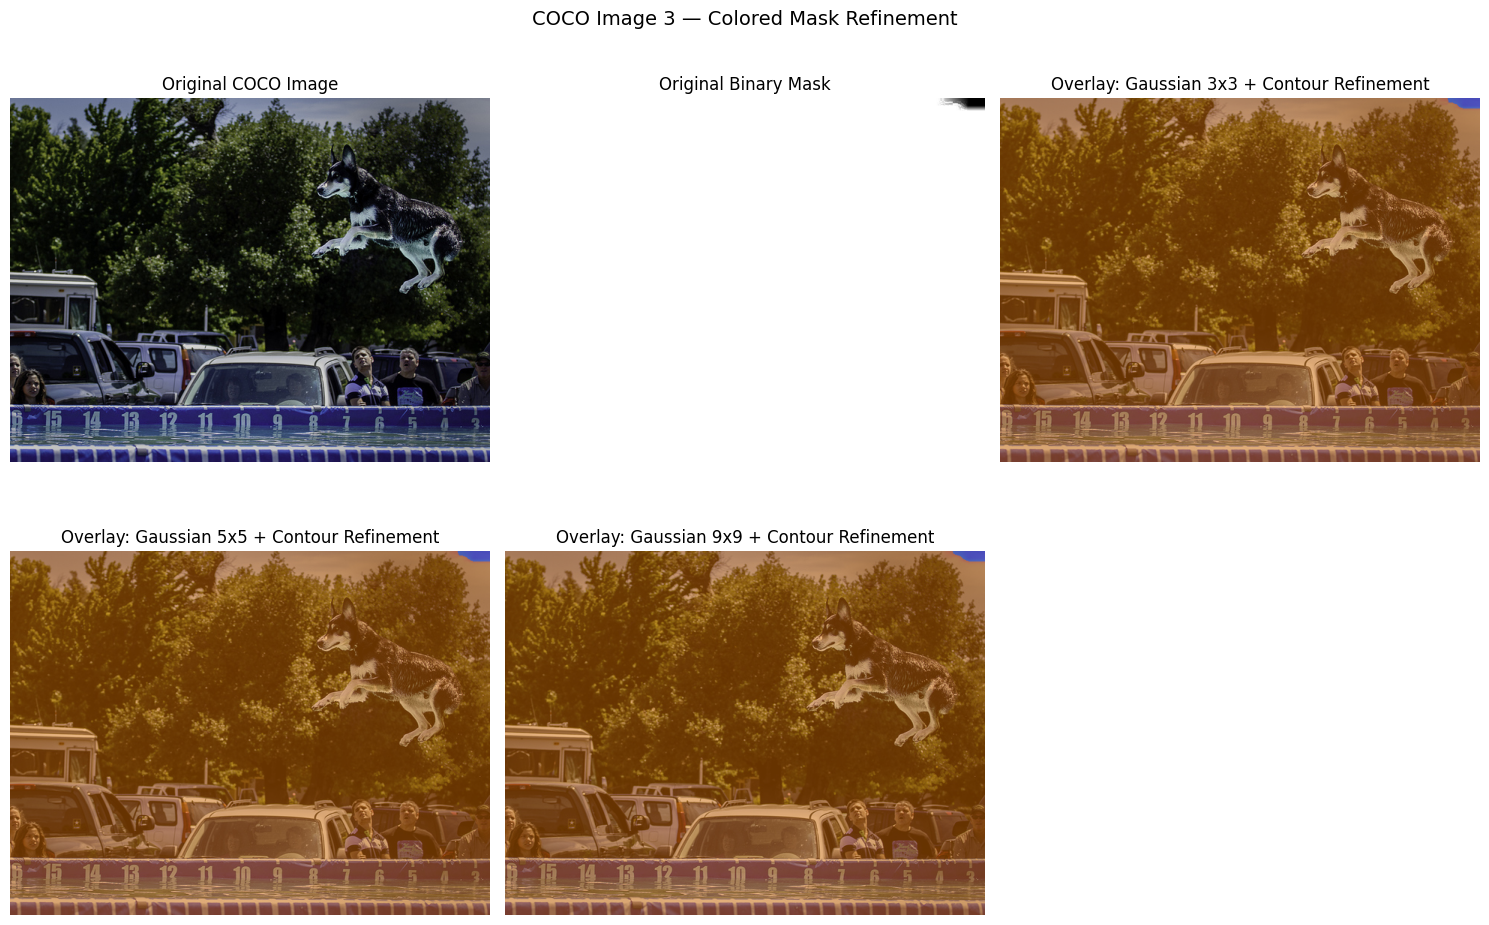

In [6]:
# ===========================================================
# STEP 1: Install + Import
# ===========================================================
!pip install fiftyone opencv-python-headless matplotlib -q

import fiftyone.zoo as foz
import fiftyone as fo
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ===========================================================
# STEP 2: Load Small COCO Dataset (Few Samples)
# ===========================================================
dataset = foz.load_zoo_dataset(
    "coco-2017",
    split="validation",
    max_samples=3,                       # small for demo
    label_types=["segmentations"],
    classes=["person", "car", "dog"],
    only_matching=True
)
print("✅ Small COCO dataset loaded")

os.makedirs("coco_masks", exist_ok=True)

# ===========================================================
# STEP 3: Export a Combined Mask for Each Image
# ===========================================================
def export_mask(sample, output_dir="coco_masks"):
    img = cv2.imread(sample.filepath)
    h, w, _ = img.shape
    mask = np.zeros((h, w), dtype=np.uint8)

    if hasattr(sample, "ground_truth") and sample.ground_truth is not None:
        for detection in sample.ground_truth.detections:
            if detection.mask is not None:
                seg = (detection.mask * 255).astype(np.uint8)
                seg = cv2.resize(seg, (w, h))
                mask = cv2.bitwise_or(mask, seg)

    out_path = f"{output_dir}/{sample.id}.png"
    cv2.imwrite(out_path, mask)
    return img, mask

# ===========================================================
# STEP 4: Gaussian Blur + Contour Refinement Function
# ===========================================================
def refine_mask_colored(mask, kernel_size):
    """Apply Gaussian blur, contour detection, refinement and colorize."""
    blurred = cv2.GaussianBlur(mask, (kernel_size, kernel_size), 0)
    _, binary = cv2.threshold(blurred, 128, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    refined = np.zeros_like(mask)
    cv2.drawContours(refined, contours, -1, 255, thickness=cv2.FILLED)
    refined = cv2.morphologyEx(refined, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))

    # Convert mask to colored version
    color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    color[..., 0] = refined           # Red channel
    color[..., 1] = blurred // 2      # Green channel
    color[..., 2] = 255 - refined     # Blue inverse for contrast

    return blurred, refined, color

# ===========================================================
# STEP 5: Visualization with Colored Overlays
# ===========================================================
kernels = [3, 5, 9]

for i, sample in enumerate(dataset.take(3)):
    img, mask = export_mask(sample)
    if mask is None:
        continue

    plt.figure(figsize=(15, 10))
    plt.subplot(2, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original COCO Image")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Original Binary Mask")
    plt.axis("off")

    # Apply Gaussian + Contour refinement at 3 kernel sizes
    for j, k in enumerate(kernels):
        blurred, refined, colored = refine_mask_colored(mask, k)
        overlay = cv2.addWeighted(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), 0.6, colored, 0.4, 0)

        plt.subplot(2, 3, j+3)
        plt.imshow(overlay)
        plt.title(f"Overlay: Gaussian {k}x{k} + Contour Refinement")
        plt.axis("off")

    plt.suptitle(f"COCO Image {i+1} — Colored Mask Refinement", fontsize=14)
    plt.tight_layout()
    plt.show()
